In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.providers.basic_provider import BasicProvider

In [2]:
backend = BasicProvider().get_backend('basic_simulator')

In [5]:
epr_circuit = QuantumCircuit(2, 2)
epr_circuit.h(0)
epr_circuit.cx(0, 1)
epr_circuit.measure([0, 1], [0, 1])

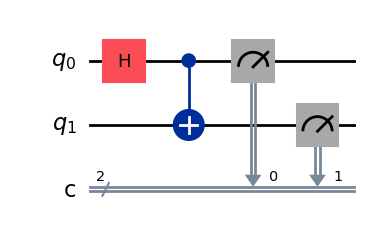

In [6]:
epr_circuit.draw("mpl")

In [11]:
singlet_circuit = QuantumCircuit(2, 2)
singlet_circuit.h(0)
singlet_circuit.x(1)
singlet_circuit.cx(0, 1)
singlet_circuit.measure([0, 1], [0, 1])

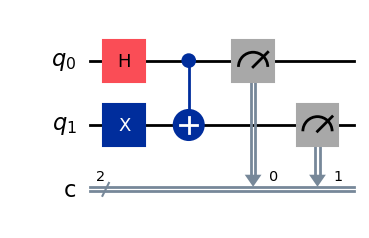

In [12]:
singlet_circuit.draw("mpl")

In [13]:
ghz_circuit = QuantumCircuit(3, 3)
ghz_circuit.h(0)
ghz_circuit.cx([0, 0], [1, 2])
ghz_circuit.measure([0, 1, 2], [0, 1, 2])

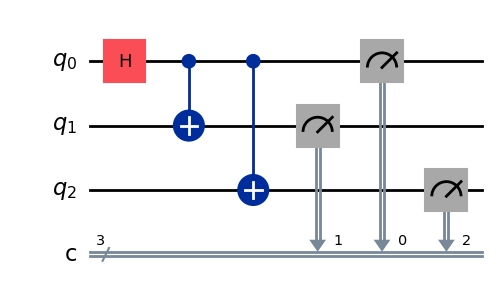

In [14]:
ghz_circuit.draw("mpl")

In [15]:
backend_simulator = BasicProvider().get_backend('basic_simulator')

In [16]:
compiled_epr_circuit = transpile(epr_circuit, backend_simulator)
epr_circuit_job = backend_simulator.run(compiled_epr_circuit, shots=1024)
epr_circuit_job.result().get_counts()

{'00': 511, '11': 513}

In [17]:
compiled_singlet_circuit = transpile(singlet_circuit, backend_simulator)
singlet_circuit_job = backend_simulator.run(compiled_singlet_circuit, shot=1024)
singlet_circuit_job.result().get_counts()

C:\Users\hok\AppData\Local\Temp\1\ipykernel_51048\1925816390.py:2: UserWarning: Option shot is not used by this backend
  singlet_circuit_job = backend_simulator.run(compiled_singlet_circuit, shot=1024)


{'01': 511, '10': 513}

In [18]:
compiled_ghz_circuit = transpile(ghz_circuit, backend_simulator)
ghz_circuit_job = backend_simulator.run(compiled_ghz_circuit, shot=1024)
ghz_circuit_job.result().get_counts()

C:\Users\hok\AppData\Local\Temp\1\ipykernel_51048\1569756831.py:2: UserWarning: Option shot is not used by this backend
  ghz_circuit_job = backend_simulator.run(compiled_ghz_circuit, shot=1024)


{'111': 518, '000': 506}